# Toy Models #
We first use Juan Kuntz's toy model from the paper "Particle algorithms for maximum likelihood training of latent variable models" by Juan Kuntz, Jen Ning Lim, Adam M. Johansen 'https://arxiv.org/pdf/2204.12965'

\begin{align}
p_\theta(x,y)=\prod_{d=1}^{D_x}{\frac{1}{2\pi}\exp\Big(-\frac{(x_d-\theta)^2}{2}-\frac{(x_d-y_d)^2}{2}\Big)}
\end{align}

Where the functional they considered was:
\begin{equation*}
\mathcal{F}(\theta,q)=\int\log\Big(\frac{q(x)}{p_\theta(x)}\Big)q(\mathrm{d}x)-\int\log(p_\theta(y\vert x))q(\mathrm{d}x)  
\end{equation*}


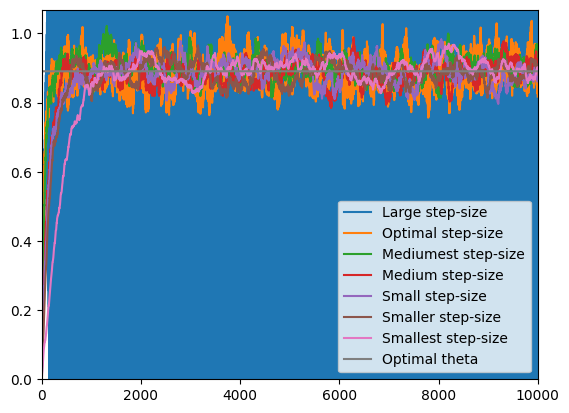

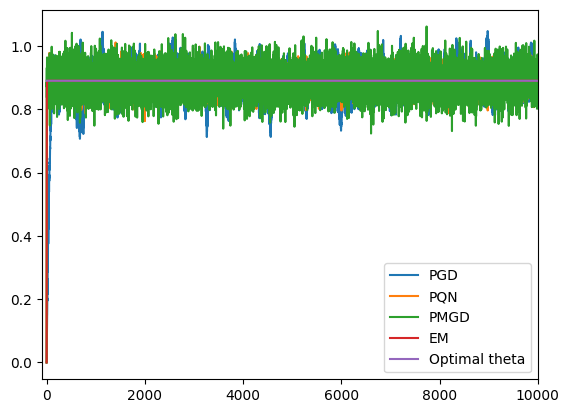

0.0


In [31]:
import numpy as np  # Numpy for computations.
import matplotlib.pyplot as plt  # Pyplot for plots.
# np.random.seed(42)
def pgd(y, h, K, N, th, X):
    """Particle Gradient Ascent Algorithm. Returns parameter estimates."""
    D = y.size  # Extract dimension of latent variables.
    for k in range(K):
        # Update parameter estimate:
        th = np.append(th, th[k] + h*ave_grad_th(th[k], X))
        # Update particle cloud:
        X = (X + h*grad_x(y, th[k], X)
               + np.sqrt(2*h)*np.random.normal(0, 1, (D, N)))
    return th


def pqn(y, h, K, N, th, X):
    """Particle Quasi-Newton Algorithm. Returns parameter estimates."""
    D = y.size  # Extract dimension of latent variables.
    for k in range(K):
        # Update parameter estimate:
        th = np.append(th, th[k] 
                            + h*(ave_neg_hess_th(D)**-1)*ave_grad_th(th[k], X))
        # Update particle cloud:
        X = (X + h*grad_x(y, th[k], X)
               + np.sqrt(2*h)*np.random.normal(0, 1, (D, N)))
    return th


def pmgd(y, h, K, N, X):
    """Particle Marginal Gradient Ascent Algorithm. 
    Returns parameter estimates.
    """
    D = y.size  # Extract dimension of latent variables.
    th = np.array([theta_opt(X)])  # Compute initial parameter estimate.
    for k in range(K):
        # Update particle cloud:
        X = (X + h*grad_x(y, th[k], X)
               + np.sqrt(2*h)*np.random.normal(0, 1, (D, N)))
        th = np.append(th, theta_opt(X))  # Update parameter estimate.
    return th


def em(y, K, th):
    """Expectation Maximization Algorithm. Returns parameter estimates."""
    for k in range(K):
        th = np.append(th, th[k]/2 + y.mean()/2)  # Update parameter estimate.
    return th


# Auxiliary functions.

def theta_opt(X):
    return X.mean()  # Return optimal parameter for particle cloud X.


def ave_grad_th(th, X):
    """Returns theta-gradient of log density averaged over particles."""
    return X[:, 0].size*(theta_opt(X) - th)


def ave_neg_hess_th(D):
    """Returns negative-theta-Hessian of log density averaged over particles.
    """
    return D


def grad_x(y, th, X):
    """Returns x-gradient of log density vectorized over particles."""
    return (y + th - 2*X)


D = 100  # Dimensionality of latent variables.
thdata = 1  # Parameter value used to generate the data.

# Generate the data:
y = np.random.normal(0, 1, (D, 1)) + np.random.normal(thdata, 1, (D, 1))

K = 10000  # Number of steps.
N = 10  # Number of particles.

th0 = np.array([0])  # Initial parameter guess.
X0 = np.zeros((D, N))  # Initial particle cloud.

# Run PGD using three different step-sizes:
th_large = pgd(y, 2.05/(2+D), K, N, th0, X0)  # Large step-size
th_optimal = pgd(y, 2/(2+D), K, N, th0, X0)  # Optimal step-size 
th_mediumest = pgd(y, 1.5/(2+D), K, N, th0, X0)  # Small step-size
th_medium = pgd(y, 1/(2+D), K, N, th0, X0)  # Small step-size
th_small = pgd(y, 0.75/(2+D), K, N, th0, X0)  # Small step-size
th_smaller = pgd(y, 0.5/(2+D), K, N, th0, X0)  # Small step-size
th_smallest = pgd(y, 0.25/(2+D), K, N, th0, X0)  # Small step-size

# Plot parameter estimates as a function of step number k:
plt.figure()
plt.plot(th_large, label='Large step-size')
plt.plot(th_optimal, label='Optimal step-size')
plt.plot(th_mediumest, label='Mediumest step-size')
plt.plot(th_medium, label='Medium step-size')
plt.plot(th_small, label='Small step-size')
plt.plot(th_smaller, label='Smaller step-size')
plt.plot(th_smallest, label='Smallest step-size')
plt.plot(y.mean()*np.ones(K), label='Optimal theta')
plt.legend(loc='lower right')
plt.ylim([0, 1.2*y.mean()])
plt.xlim([0, K])
plt.show()

# Run the algorithms using the optimal step-sizes:
th_pgd = pgd(y, 2/(2+D), K, N, th0, X0)
th_pqn = pqn(y, 2/3, K, N, th0, X0)
th_pmgd = pmgd(y, 1, K, N, X0)
th_em = em(y, K, th0)


# Plot parameter estimates as a function of step number k:
plt.figure()
plt.plot(th_pgd, label='PGD')
plt.plot(th_pqn, label='PQN')
plt.plot(th_pmgd, label='PMGD')
plt.plot(th_em, label='EM')
plt.plot(y.mean()*np.ones(K), label='Optimal theta')
plt.legend(loc='lower right')
plt.xlim([-K/100, K])
plt.show()

print(theta_opt(X0))

## Nonlinear loss ##
We now introduce the log score loss we considered.
\begin{align}
\mathcal{L}(\theta,q)=-\frac{1}{\lambda_M}\sum_{i=1}^M{\log\Big(\int{p_\theta(y_i\vert{x})q(\mathrm{d}x)}}\Big)
\end{align}


/var/folders/mz/nwdfyqjs4g70s89xqtjwqfvr0000gn/T/ipykernel_15306/246935083.py:51: RuntimeWarning: invalid value encountered in divide
  Normalised=np.exp(-1/2*np.sum((X-y)**2,axis=0))/Z


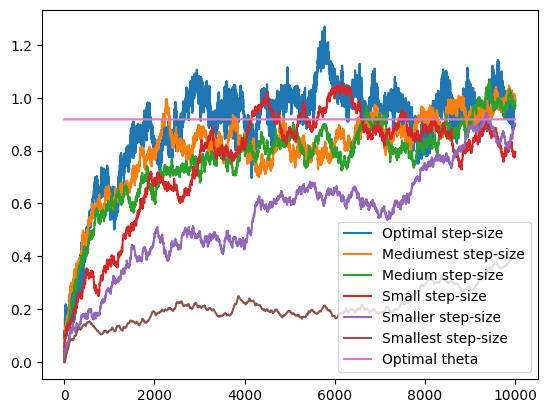

In [32]:
np.random.seed(42)
thdata = 1
# np.random.seed(42)
D=100
y = np.random.normal(0, 1, (D, 1)) + np.random.normal(thdata, 1, (D, 1))

# epsilon = 0.1  # 10% outliers
# num_outliers = int(D * epsilon)

# # Randomly select indices for outliers
# outlier_indices = np.random.choice(D, num_outliers, replace=False)

# # Add large noise to those observations
# y[outlier_indices] += np.random.normal(0, 10, num_outliers).reshape(-1, 1)


K = 10000  # Number of steps.
N = 10  # Number of particles.

th0 = np.array([0])  # Initial parameter guess.
X0 = np.ones((D, N))  # Initial particle cloud.
def summed(X0,y):
    Term=0
    for n in range(N):
        Term+=np.exp(-1/2*np.sum((y-X0[:,n])**2))
    return Term


def theta_opt(X):
    return X.mean()  # Return optimal parameter for particle cloud X.

def ave_grad_th(th, X):
    """Returns theta-gradient of log density averaged over particles."""
    return X[:, 0].size*(theta_opt(X) - th)


def grad_x(y, th, X):
    """Returns x-gradient of log density vectorized over particles."""
    return (th - X)


def Nonlinear_pgd(y, h, K, N, th,lN, X):
    """Particle Gradient Ascent Algorithm. Returns parameter estimates."""
    D = y.size  # Extract dimension of latent variables.
    for k in range(K):
        # Update parameter estimate:
        th = np.append(th, th[k] + h*ave_grad_th(th[k], X))
        # Update particle cloud:
        Z=np.mean(np.exp(-1/2*np.sum((X-y)**2,axis=0)))
        # print(Z)
        Normalised=np.exp(-1/2*np.sum((X-y)**2,axis=0))/Z
        # print(Normalised.shape)
        X = (X + h*(grad_x(y, th[k], X)
               +lN*(y-X)*Normalised)+ np.sqrt(2*h)*np.random.normal(0, 1, (D, N)))
    # print((lN*(y-X)*Normalised).shape)
    return th

th0 = np.array([0])  # Initial parameter guess.
X0 = np.zeros((D, N))  # Initial particle cloud.

# Run PGD using three different step-sizes:
th_large = Nonlinear_pgd(y, 2.05/(2+D), K, N, th0, 1, X0)  # Large step-size
th_optimal = Nonlinear_pgd(y, 2/(2+D), K, N, th0,1, X0)  # Optimal step-size 
th_mediumest = Nonlinear_pgd(y, 1.5/(2+D), K, N, th0,1, X0)  # Small step-size
th_medium = Nonlinear_pgd(y, 1/(2+D), K, N, th0,1, X0)  # Small step-size
th_small = Nonlinear_pgd(y, 0.75/(2+D), K, N, th0,1, X0)  # Small step-size
th_smaller = Nonlinear_pgd(y, 0.5/(2+D), K, N, th0,1, X0)  # Small step-size
th_smallest = Nonlinear_pgd(y, 0.1/(2+D), K, N, th0,1, X0)  # Small step-size

# Plot parameter estimates as a function of step number k:
plt.figure()
# plt.plot(th_large, label='Large step-size') # We don't include the one which blows up
plt.plot(th_optimal, label='Optimal step-size')
plt.plot(th_mediumest, label='Mediumest step-size')
plt.plot(th_medium, label='Medium step-size')
plt.plot(th_small, label='Small step-size')
plt.plot(th_smaller, label='Smaller step-size')
plt.plot(th_smallest, label='Smallest step-size')
plt.plot(y.mean()*np.ones(K), label='Optimal theta')
plt.legend(loc='lower right')
# plt.ylim([0, 2*y.mean()])
# plt.xlim([0, K])
plt.show()


### Same model but different code ###
Sometimes they would do the leave one out method for the interacting term in the sum (see notes for more details)

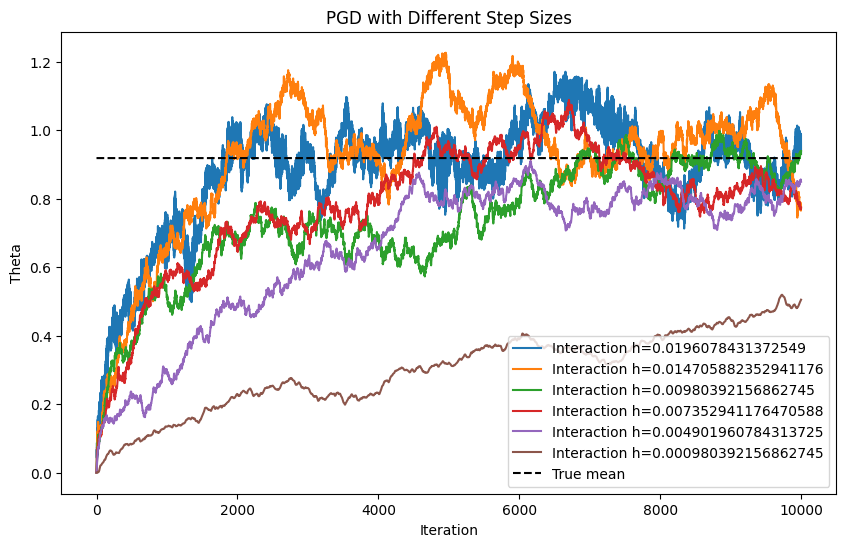

In [33]:
np.random.seed(42)
thdata = 1
# np.random.seed(42)
D=100
M=1
y = np.random.normal(0, 1, (D, M)) + np.random.normal(thdata, 1, (D, M))

epsilon = 0.1  # 10% outliers
num_outliers = int(D * epsilon)

# Randomly select indices for outliers
outlier_indices = np.random.choice(D, num_outliers, replace=False)

# Add large noise to those observations
# y[outlier_indices] += np.random.normal(0, 10, num_outliers).reshape(-1, 1)


K = 10000  # Number of steps.
N = 10  # Number of particles.

th0 = np.array([0])  # Initial parameter guess.
X0 = np.zeros((D, N))  # Initial particle cloud.

def theta_opt(X):
    return X.mean()  # Return optimal parameter for particle cloud X.

def ave_grad_th(th, X):
    """Returns theta-gradient of log density averaged over particles."""
    return X[:, 0].size*(theta_opt(X) - th)


def grad_x(y, th, X):
    """Returns x-gradient of log density vectorized over particles."""
    return (th - X)


def interaction_force(Y, Xk, lambda_M):
    # Y: (D, M), Xk: (D, N)
    
    D, M = Y.shape
    _, N = Xk.shape
    
    diff = Y[:, :, None] - Xk[:, None, :]     # (D, M, N)
    sq_dist = np.sum(diff**2, axis=0)         # (M, N)
    
    weights = np.exp(-0.5 * sq_dist)          # (M, N)
    
    Z = np.mean(weights, axis=1, keepdims=True)   # (M, 1)
    
    P = weights / Z                           # (M, N)
    # print('Interaction',weights)
    forces = diff * P[None, :, :]             # (D, M, N)
    
    return np.sum(forces, axis=1) / lambda_M  # (D, N)
# print(interaction_force(Y, Xk,1))


def interaction_force_no_self(Y, Xk, lambda_M):
    D, M = Y.shape
    _, N = Xk.shape
    
    diff = Y[:, :, None] - Xk[:, None, :]
    sq_dist = np.sum(diff**2, axis=0)
    
    weights = np.exp(-0.5 * sq_dist)
    
    total = np.sum(weights, axis=1, keepdims=True)   # (M,1)
    Z = (total - weights) / (N - 1)                  # (M,N)
    
    P = weights / Z
    
    forces = diff * P[None, :, :]
    
    return np.sum(forces, axis=1) / lambda_M
# print(interaction_force_no_self(y, Xk,1))


def Nonlinear_pgd(y, h, K, N, th, lN, X, mode="interaction"):
    D = y.shape[0]
    
    for k in range(K):
        # --- theta update ---
        th = np.append(th, th[k] + h * ave_grad_th(th[k], X))
        
        # --- interaction term ---
        if mode == "interaction":
            inter = interaction_force(y, X,lN)
        elif mode == "no_self":
            inter = interaction_force_no_self(y, X,lN)
        else:
            raise ValueError("mode must be 'interaction' or 'no_self'")
        
        # --- particle update ---
        X = (X 
             + h * (grad_x(y, th[k], X) + lN * inter)
             + np.sqrt(2*h) * np.random.normal(0, 1, (D, N)))
    return th,X

step_sizes = [2/(2+D),1.5/(2+D),1/(2+D),0.75/(2+D),0.5/(2+D),0.1/(2+D)]  # Example step sizes
results = {}

for h in step_sizes:
    th_inter, X_inter = Nonlinear_pgd(y, h, K, N, th0.copy(), 1, X0.copy(), mode="interaction")
    # th_no_inter, X_no_inter = Nonlinear_pgd(y, h, K, N, th0.copy(), 1, X0.copy(), mode="no_self")
    
    results[h] = {
        "interaction": th_inter
        # "no_interaction": th_no_inter
    }

# --- Plot results ---
plt.figure(figsize=(10,6))

for h in step_sizes:
    plt.plot(results[h]["interaction"], label=f'Interaction h={h}')
    # plt.plot(results[h]["no_interaction"], linestyle='--', label=f'No self h={h}')

plt.plot(y.mean()*np.ones(K), 'k--', label='True mean')
plt.xlabel("Iteration")
plt.ylabel("Theta")
plt.title("PGD with Different Step Sizes")
plt.legend()
plt.show()


We try doing the non interacting term i.e. in the discrete sum we leave out the nth term when updating the nth particle.

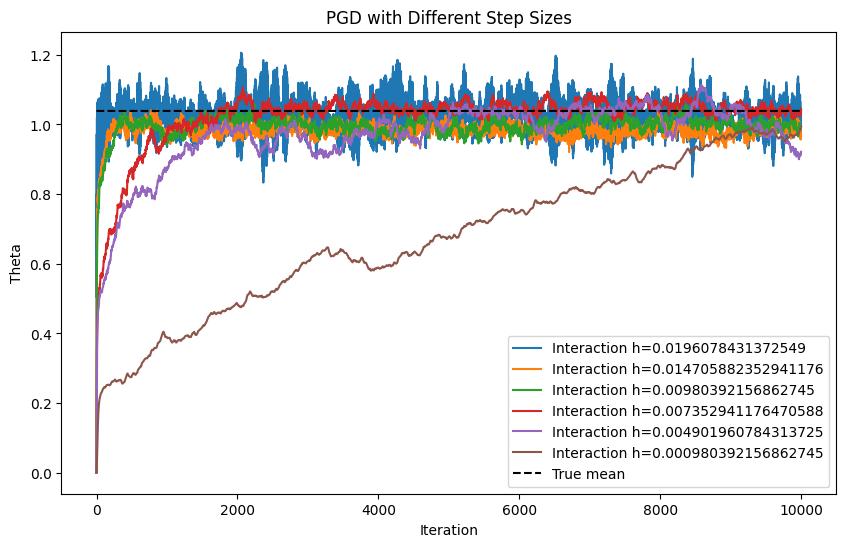

In [ ]:
np.random.seed(42)
thdata = 1

D=100
'''Increase the number of samples'''
M=20 
y = np.random.normal(0, 1, (D, M)) + np.random.normal(thdata, 1, (D, M))

epsilon = 0.1  # 10% outliers
num_outliers = int(D * epsilon)

# Randomly select indices for outliers
outlier_indices = np.random.choice(D, num_outliers, replace=False)

# Add large noise to those observations
# y[outlier_indices] += np.random.normal(0, 10, num_outliers).reshape(-1, 1)


K = 10000  # Number of steps.
N = 10  # Number of particles.

th0 = np.array([0])  # Initial parameter guess.
X0 = np.zeros((D, N))  # Initial particle cloud.

def theta_opt(X):
    return X.mean()  # Return optimal parameter for particle cloud X.

def ave_grad_th(th, X):
    """Returns theta-gradient of log density averaged over particles."""
    return X[:, 0].size*(theta_opt(X) - th)


def grad_x(y, th, X):
    """Returns x-gradient of log density vectorized over particles."""
    return (th - X)


def interaction_force(Y, Xk, lambda_M):
    # Y: (D, M), Xk: (D, N)
    
    D, M = Y.shape
    _, N = Xk.shape
    
    diff = Y[:, :, None] - Xk[:, None, :]     # (D, M, N)
    sq_dist = np.sum(diff**2, axis=0)         # (M, N)
    
    weights = np.exp(-0.5 * sq_dist)          # (M, N)
    
    Z = np.mean(weights, axis=1, keepdims=True)   # (M, 1)
    
    P = weights / Z                           # (M, N)
    # print('Interaction',weights)
    forces = diff * P[None, :, :]             # (D, M, N)
    
    return np.sum(forces, axis=1) / lambda_M  # (D, N)
# print(interaction_force(Y, Xk,1))


def interaction_force_no_self(Y, Xk, lambda_M):
    D, M = Y.shape
    _, N = Xk.shape
    
    diff = Y[:, :, None] - Xk[:, None, :]
    sq_dist = np.sum(diff**2, axis=0)
    
    weights = np.exp(-0.5 * sq_dist)
    
    total = np.sum(weights, axis=1, keepdims=True)   # (M,1)
    Z = (total - weights) / (N - 1)                  # (M,N)
    
    P = weights / Z
    
    forces = diff * P[None, :, :]
    
    return np.sum(forces, axis=1) / lambda_M
# print(interaction_force_no_self(y, Xk,1))


def Nonlinear_pgd(y, h, K, N, th, lN, X, mode="interaction"):
    D = y.shape[0]
    
    for k in range(K):
        # --- theta update ---
        th = np.append(th, th[k] + h * ave_grad_th(th[k], X))
        
        # --- interaction term ---
        if mode == "interaction":
            inter = interaction_force(y, X,lN)
        elif mode == "no_self":
            inter = interaction_force_no_self(y, X,lN)
        else:
            raise ValueError("mode must be 'interaction' or 'no_self'")
        
        # --- particle update ---
        X = (X 
             + h * (grad_x(y, th[k], X) + lN * inter)
             + np.sqrt(2*h) * np.random.normal(0, 1, (D, N)))
    return th,X


# th_inter,X_inter = Nonlinear_pgd(y, 1/(2+D), K, N, th0, 1, X0.copy(), mode="interaction")

# th_no_inter,X_no_inter = Nonlinear_pgd(y, 1/(2+D), K, N, th0, 1, X0.copy(), mode="no_self")

# print(th_inter)
# print(th_no_inter)

# plt.figure()

# plt.plot(th_inter, label='Interaction')
# plt.plot(th_no_inter, label='No self-interaction')

# plt.plot(y.mean()*np.ones(K), '--', label='True mean')

# plt.legend()
# plt.title("Interaction vs Non-interaction PGD")
# plt.show()


step_sizes = [2/(2+D),1.5/(2+D),1/(2+D),0.75/(2+D),0.5/(2+D),0.1/(2+D)]  # Example step sizes
results = {}

for h in step_sizes:
    th_inter, X_inter = Nonlinear_pgd(y, h, K, N, th0.copy(), 1, X0.copy(), mode="interaction")
    # th_no_inter, X_no_inter = Nonlinear_pgd(y, h, K, N, th0.copy(), 1, X0.copy(), mode="no_self")
    
    results[h] = {
        "interaction": th_inter,
        # "no_interaction": th_no_inter
    }

# --- Plot results ---
plt.figure(figsize=(10,6))

for h in step_sizes:
    plt.plot(results[h]["interaction"], label=f'Interaction h={h}')
    # plt.plot(results[h]["no_interaction"], linestyle='--', label=f'No self h={h}')

plt.plot(y.mean()*np.ones(K), 'k--', label='True mean')
plt.xlabel("Iteration")
plt.ylabel("Theta")
plt.title("PGD with Different Step Sizes")
plt.legend()
plt.show()


Here I tried the no self-interaction but I think theres a mistake in the code.

/var/folders/mz/nwdfyqjs4g70s89xqtjwqfvr0000gn/T/ipykernel_15306/3779615417.py:70: RuntimeWarning: divide by zero encountered in divide
  P = weights / Z
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:118: RuntimeWarning: invalid value encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/var/folders/mz/nwdfyqjs4g70s89xqtjwqfvr0000gn/T/ipykernel_15306/3779615417.py:72: RuntimeWarning: invalid value encountered in multiply
  forces = diff * P[None, :, :]
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/var/folders/mz/nwdfyqjs4g70s89xqtjwqfvr0000gn/T/ipykernel_15306/3779615417.py:70: RuntimeWarning: invalid value encountered in divide
  P = weights / Z


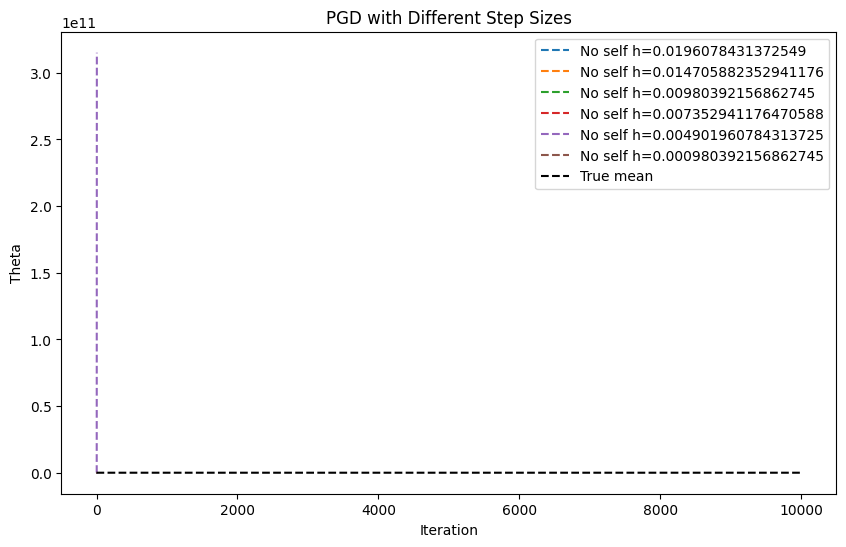

In [35]:
np.random.seed(42)
thdata = 1
# np.random.seed(42)
D=100
M=20
y = np.random.normal(0, 1, (D, M)) + np.random.normal(thdata, 1, (D, M))

epsilon = 0.1  # 10% outliers
num_outliers = int(D * epsilon)

# Randomly select indices for outliers
outlier_indices = np.random.choice(D, num_outliers, replace=False)

# Add large noise to those observations
# y[outlier_indices] += np.random.normal(0, 10, num_outliers).reshape(-1, 1)


K = 10000  # Number of steps.
N = 10  # Number of particles.

th0 = np.array([0])  # Initial parameter guess.
X0 = np.zeros((D, N))  # Initial particle cloud.

def theta_opt(X):
    return X.mean()  # Return optimal parameter for particle cloud X.

def ave_grad_th(th, X):
    """Returns theta-gradient of log density averaged over particles."""
    return X[:, 0].size*(theta_opt(X) - th)


def grad_x(y, th, X):
    """Returns x-gradient of log density vectorized over particles."""
    return (th - X)


def interaction_force(Y, Xk, lambda_M):
    # Y: (D, M), Xk: (D, N)
    
    D, M = Y.shape
    _, N = Xk.shape
    
    diff = Y[:, :, None] - Xk[:, None, :]     # (D, M, N)
    sq_dist = np.sum(diff**2, axis=0)         # (M, N)
    
    weights = np.exp(-0.5 * sq_dist)          # (M, N)
    
    Z = np.mean(weights, axis=1, keepdims=True)   # (M, 1)
    
    P = weights / Z                           # (M, N)
    # print('Interaction',weights)
    forces = diff * P[None, :, :]             # (D, M, N)
    
    return np.sum(forces, axis=1) / lambda_M  # (D, N)
# print(interaction_force(Y, Xk,1))


def interaction_force_no_self(Y, Xk, lambda_M):
    D, M = Y.shape
    _, N = Xk.shape
    
    diff = Y[:, :, None] - Xk[:, None, :]
    sq_dist = np.sum(diff**2, axis=0)
    
    weights = np.exp(-0.5 * sq_dist)
    
    total = np.sum(weights, axis=1, keepdims=True)   # (M,1)
    Z = (total - weights) / (N - 1)                  # (M,N)
    
    P = weights / Z
    
    forces = diff * P[None, :, :]
    
    return np.sum(forces, axis=1) / lambda_M
# print(interaction_force_no_self(y, Xk,1))


def Nonlinear_pgd(y, h, K, N, th, lN, X, mode="interaction"):
    D = y.shape[0]
    
    for k in range(K):
        # --- theta update ---
        th = np.append(th, th[k] + h * ave_grad_th(th[k], X))
        
        # --- interaction term ---
        if mode == "interaction":
            inter = interaction_force(y, X,lN)
        elif mode == "no_self":
            inter = interaction_force_no_self(y, X,lN)
        else:
            raise ValueError("mode must be 'interaction' or 'no_self'")
        
        # --- particle update ---
        X = (X 
             + h * (grad_x(y, th[k], X) + lN * inter)
             + np.sqrt(2*h) * np.random.normal(0, 1, (D, N)))
    return th,X


# th_inter,X_inter = Nonlinear_pgd(y, 1/(2+D), K, N, th0, 1, X0.copy(), mode="interaction")

# th_no_inter,X_no_inter = Nonlinear_pgd(y, 1/(2+D), K, N, th0, 1, X0.copy(), mode="no_self")

# print(th_inter)
# print(th_no_inter)

# plt.figure()

# plt.plot(th_inter, label='Interaction')
# plt.plot(th_no_inter, label='No self-interaction')

# plt.plot(y.mean()*np.ones(K), '--', label='True mean')

# plt.legend()
# plt.title("Interaction vs Non-interaction PGD")
# plt.show()


step_sizes = [2/(2+D),1.5/(2+D),1/(2+D),0.75/(2+D),0.5/(2+D),0.1/(2+D)]  # Example step sizes
results = {}

for h in step_sizes:
    # th_inter, X_inter = Nonlinear_pgd(y, h, K, N, th0.copy(), 1, X0.copy(), mode="interaction")
    th_no_inter, X_no_inter = Nonlinear_pgd(y, h, K, N, th0.copy(), 1, X0.copy(), mode="no_self")
    
    results[h] = {
        # "interaction": th_inter,
        "no_interaction": th_no_inter
    }

# --- Plot results ---
plt.figure(figsize=(10,6))

for h in step_sizes:
    # plt.plot(results[h]["interaction"], label=f'Interaction h={h}')
    plt.plot(results[h]["no_interaction"], linestyle='--', label=f'No self h={h}')

plt.plot(y.mean()*np.ones(K), 'k--', label='True mean')
plt.xlabel("Iteration")
plt.ylabel("Theta")
plt.title("PGD with Different Step Sizes")
plt.legend()
plt.show()


We can also use the logsumexp trick in the algorithm to make it more stable?

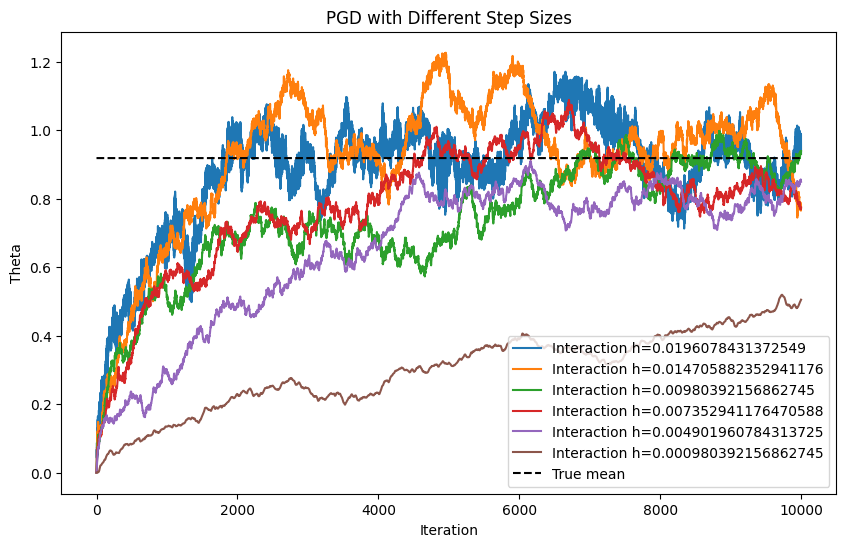

In [36]:
np.random.seed(42)
thdata = 1
# np.random.seed(42)
D=100
M=1
y = np.random.normal(0, 1, (D, M)) + np.random.normal(thdata, 1, (D, M))

epsilon = 0.1  # 10% outliers
num_outliers = int(D * epsilon)

# Randomly select indices for outliers
outlier_indices = np.random.choice(D, num_outliers, replace=False)

# Add large noise to those observations
# y[outlier_indices] += np.random.normal(0, 10, num_outliers).reshape(-1, 1)


K = 10000  # Number of steps.
N = 10  # Number of particles.

th0 = np.array([0])  # Initial parameter guess.
X0 = np.zeros((D, N))  # Initial particle cloud.

def theta_opt(X):
    return X.mean()  # Return optimal parameter for particle cloud X.

def ave_grad_th(th, X):
    """Returns theta-gradient of log density averaged over particles."""
    return X[:, 0].size*(theta_opt(X) - th)


def grad_x(y, th, X):
    """Returns x-gradient of log density vectorized over particles."""
    return (th - X)


def interaction_force(Y, Xk, lambda_M):
    D, M = Y.shape
    _, N = Xk.shape
    
    diff = Y[:, :, None] - Xk[:, None, :]        # (D, M, N)
    sq_dist = np.sum(diff**2, axis=0)            # (M, N)
    
    log_w = -0.5 * sq_dist                       # (M, N)
    
    # log-sum-exp trick
    max_log_w = np.max(log_w, axis=1, keepdims=True)   # (M,1)
    w_shifted = np.exp(log_w - max_log_w)              # stable
    
    Z = np.mean(w_shifted, axis=1, keepdims=True)      # (M,1)
    
    P = w_shifted / Z                                 # (M,N)
    
    forces = diff * P[None, :, :]                     # (D,M,N)
    
    return np.sum(forces, axis=1) / lambda_M
# print(interaction_force(Y, Xk,1))


def interaction_force_no_self(Y, Xk, lambda_M):
    D, M = Y.shape
    _, N = Xk.shape
    
    diff = Y[:, :, None] - Xk[:, None, :]
    sq_dist = np.sum(diff**2, axis=0)
    log_w = -0.5 * sq_dist   
    # weights = np.exp(-0.5 * sq_dist)
    max_log_w = np.max(log_w, axis=1, keepdims=True)   # (M,1)
    w_shifted = np.exp(log_w - max_log_w)              # stable
    
    total = np.sum(w_shifted, axis=1, keepdims=True)   # (M,1)
    Z = (total - w_shifted) / (N - 1)                  # (M,N)
    
    P = w_shifted / Z
    
    forces = diff * P[None, :, :]
    
    return np.sum(forces, axis=1) / lambda_M
# print(interaction_force_no_self(y, Xk,1))


def Nonlinear_pgd(y, h, K, N, th, lN, X, mode="interaction"):
    D = y.shape[0]
    
    for k in range(K):
        # --- theta update ---
        th = np.append(th, th[k] + h * ave_grad_th(th[k], X))
        
        # --- interaction term ---
        if mode == "interaction":
            inter = interaction_force(y, X,lN)
        elif mode == "no_self":
            inter = interaction_force_no_self(y, X,lN)
        else:
            raise ValueError("mode must be 'interaction' or 'no_self'")
        
        # --- particle update ---
        X = (X 
             + h * (grad_x(y, th[k], X) + lN * inter)
             + np.sqrt(2*h) * np.random.normal(0, 1, (D, N)))
    return th,X



step_sizes = [2/(2+D),1.5/(2+D),1/(2+D),0.75/(2+D),0.5/(2+D),0.1/(2+D)]  # Example step sizes
results = {}

for h in step_sizes:
    th_inter, X_inter = Nonlinear_pgd(y, h, K, N, th0.copy(), 1, X0.copy(), mode="interaction")
    # th_no_inter, X_no_inter = Nonlinear_pgd(y, h, K, N, th0.copy(), 1, X0.copy(), mode="no_self")
    
    results[h] = {
        "interaction": th_inter
        # "no_interaction": th_no_inter
    }

# --- Plot results ---
plt.figure(figsize=(10,6))

for h in step_sizes:
    plt.plot(results[h]["interaction"], label=f'Interaction h={h}')
    # plt.plot(results[h]["no_interaction"], linestyle='--', label=f'No self h={h}')

plt.plot(y.mean()*np.ones(K), 'k--', label='True mean')
plt.xlabel("Iteration")
plt.ylabel("Theta")
plt.title("PGD with Different Step Sizes")
plt.legend()
plt.show()


## Adding outlier noise ##
(I think this is correct)

First for the 'linear' PGD

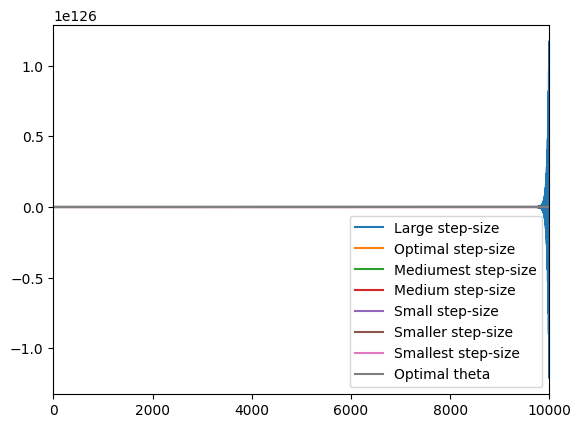

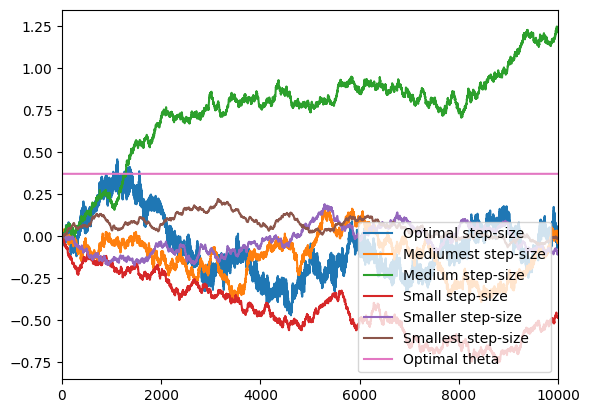

In [37]:
D = 100
thdata = 1

y = np.random.normal(0, 1, (D, 1)) + np.random.normal(thdata, 1, (D, 1))

epsilon = 0.1  # 10% outliers
num_outliers = int(D * epsilon)

# Randomly select indices for outliers
outlier_indices = np.random.choice(D, num_outliers, replace=False)

# Add large noise to those observations
y[outlier_indices] += np.random.normal(0, 10, num_outliers).reshape(-1, 1)



K = 10000  # Number of steps.
N = 10  # Number of particles.

th0 = np.array([0])  # Initial parameter guess.
X0 = np.zeros((D, N))  # Initial particle cloud.

# Run PGD using three different step-sizes:
th_large = pgd(y, 2.05/(2+D), K, N, th0, X0)  # Large step-size
th_optimal = pgd(y, 2/(2+D), K, N, th0, X0)  # Optimal step-size 
th_mediumest = pgd(y, 1.5/(2+D), K, N, th0, X0)  # Small step-size
th_medium = pgd(y, 1/(2+D), K, N, th0, X0)  # Small step-size
th_small = pgd(y, 0.75/(2+D), K, N, th0, X0)  # Small step-size
th_smaller = pgd(y, 0.5/(2+D), K, N, th0, X0)  # Small step-size
th_smallest = pgd(y, 0.25/(2+D), K, N, th0, X0)  # Small step-size

# Plot parameter estimates as a function of step number k:
plt.figure()
plt.plot(th_large, label='Large step-size')
plt.plot(th_optimal, label='Optimal step-size')
plt.plot(th_mediumest, label='Mediumest step-size')
plt.plot(th_medium, label='Medium step-size')
plt.plot(th_small, label='Small step-size')
plt.plot(th_smaller, label='Smaller step-size')
plt.plot(th_smallest, label='Smallest step-size')
plt.plot(y.mean()*np.ones(K), label='Optimal theta')
plt.legend(loc='lower right')
# plt.ylim([0, 1.2*y.mean()])
plt.xlim([0, K])
plt.show()

'''Without the largest step size'''
plt.figure()
# plt.plot(th_large, label='Large step-size')
plt.plot(th_optimal, label='Optimal step-size')
plt.plot(th_mediumest, label='Mediumest step-size')
plt.plot(th_medium, label='Medium step-size')
plt.plot(th_small, label='Small step-size')
plt.plot(th_smaller, label='Smaller step-size')
plt.plot(th_smallest, label='Smallest step-size')
plt.plot(y.mean()*np.ones(K), label='Optimal theta')
plt.legend(loc='lower right')
# plt.ylim([0, 1.2*y.mean()])
plt.xlim([0, K])
plt.show()


## For our 'nonlinear' with and without the self interaction ##

/var/folders/mz/nwdfyqjs4g70s89xqtjwqfvr0000gn/T/ipykernel_15306/2754694820.py:50: RuntimeWarning: invalid value encountered in divide
  P = weights / Z                           # (M, N)


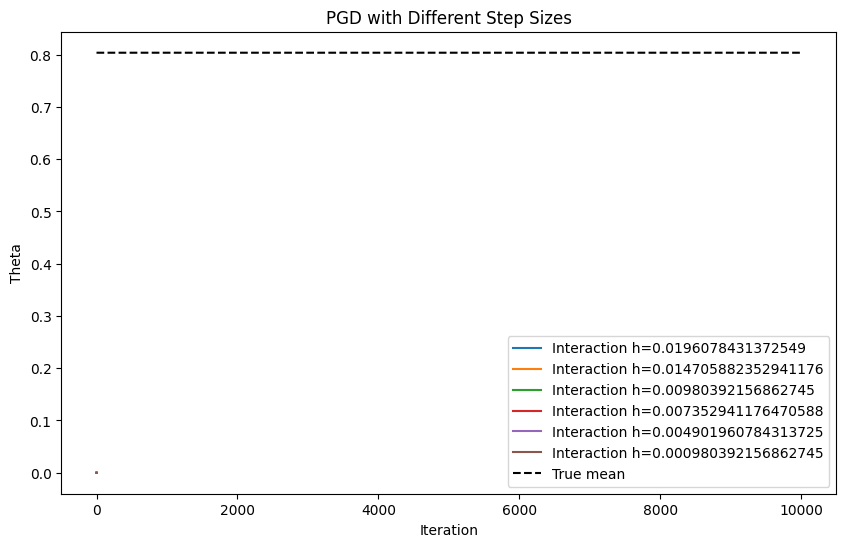

In [38]:
np.random.seed(42)
thdata = 1
# np.random.seed(42)
D=100
M=1
y = np.random.normal(0, 1, (D, M)) + np.random.normal(thdata, 1, (D, M))

epsilon = 0.1  # 10% outliers
num_outliers = int(D * epsilon)

# Randomly select indices for outliers
outlier_indices = np.random.choice(D, num_outliers, replace=False)

# Add large noise to those observations
y[outlier_indices] += np.random.normal(0, 10, num_outliers).reshape(-1, 1)


K = 10000  # Number of steps.
N = 10  # Number of particles.

th0 = np.array([0])  # Initial parameter guess.
X0 = np.zeros((D, N))  # Initial particle cloud.

def theta_opt(X):
    return X.mean()  # Return optimal parameter for particle cloud X.

def ave_grad_th(th, X):
    """Returns theta-gradient of log density averaged over particles."""
    return X[:, 0].size*(theta_opt(X) - th)


def grad_x(y, th, X):
    """Returns x-gradient of log density vectorized over particles."""
    return (th - X)


def interaction_force(Y, Xk, lambda_M):
    # Y: (D, M), Xk: (D, N)
    
    D, M = Y.shape
    _, N = Xk.shape
    
    diff = Y[:, :, None] - Xk[:, None, :]     # (D, M, N)
    sq_dist = np.sum(diff**2, axis=0)         # (M, N)
    
    weights = np.exp(-0.5 * sq_dist)          # (M, N)
    
    Z = np.mean(weights, axis=1, keepdims=True)   # (M, 1)
    
    P = weights / Z                           # (M, N)
    # print('Interaction',weights)
    forces = diff * P[None, :, :]             # (D, M, N)
    
    return np.sum(forces, axis=1) / lambda_M  # (D, N)
# print(interaction_force(Y, Xk,1))


def interaction_force_no_self(Y, Xk, lambda_M):
    D, M = Y.shape
    _, N = Xk.shape
    
    diff = Y[:, :, None] - Xk[:, None, :]
    sq_dist = np.sum(diff**2, axis=0)
    
    weights = np.exp(-0.5 * sq_dist)
    
    total = np.sum(weights, axis=1, keepdims=True)   # (M,1)
    Z = (total - weights) / (N - 1)                  # (M,N)
    
    P = weights / Z
    
    forces = diff * P[None, :, :]
    
    return np.sum(forces, axis=1) / lambda_M
# print(interaction_force_no_self(y, Xk,1))


def Nonlinear_pgd(y, h, K, N, th, lN, X, mode="interaction"):
    D = y.shape[0]
    
    for k in range(K):
        # --- theta update ---
        th = np.append(th, th[k] + h * ave_grad_th(th[k], X))
        
        # --- interaction term ---
        if mode == "interaction":
            inter = interaction_force(y, X,lN)
        elif mode == "no_self":
            inter = interaction_force_no_self(y, X,lN)
        else:
            raise ValueError("mode must be 'interaction' or 'no_self'")
        
        # --- particle update ---
        X = (X 
             + h * (grad_x(y, th[k], X) + lN * inter)
             + np.sqrt(2*h) * np.random.normal(0, 1, (D, N)))
    return th,X


# th_inter,X_inter = Nonlinear_pgd(y, 1/(2+D), K, N, th0, 1, X0.copy(), mode="interaction")

# th_no_inter,X_no_inter = Nonlinear_pgd(y, 1/(2+D), K, N, th0, 1, X0.copy(), mode="no_self")

# print(th_inter)
# print(th_no_inter)

# plt.figure()

# plt.plot(th_inter, label='Interaction')
# plt.plot(th_no_inter, label='No self-interaction')

# plt.plot(y.mean()*np.ones(K), '--', label='True mean')

# plt.legend()
# plt.title("Interaction vs Non-interaction PGD")
# plt.show()


step_sizes = [2/(2+D),1.5/(2+D),1/(2+D),0.75/(2+D),0.5/(2+D),0.1/(2+D)]  # Example step sizes
results = {}

for h in step_sizes:
    th_inter, X_inter = Nonlinear_pgd(y, h, K, N, th0.copy(), 1, X0.copy(), mode="interaction")
    # th_no_inter, X_no_inter = Nonlinear_pgd(y, h, K, N, th0.copy(), 1, X0.copy(), mode="no_self")
    
    results[h] = {
        "interaction": th_inter
        # "no_interaction": th_no_inter
    }

# --- Plot results ---
plt.figure(figsize=(10,6))

for h in step_sizes:
    plt.plot(results[h]["interaction"], label=f'Interaction h={h}')
    # plt.plot(results[h]["no_interaction"], linestyle='--', label=f'No self h={h}')

plt.plot(y.mean()*np.ones(K), 'k--', label='True mean')
plt.xlabel("Iteration")
plt.ylabel("Theta")
plt.title("PGD with Different Step Sizes")
plt.legend()
plt.show()


/var/folders/mz/nwdfyqjs4g70s89xqtjwqfvr0000gn/T/ipykernel_15306/1858320717.py:70: RuntimeWarning: invalid value encountered in divide
  P = weights / Z


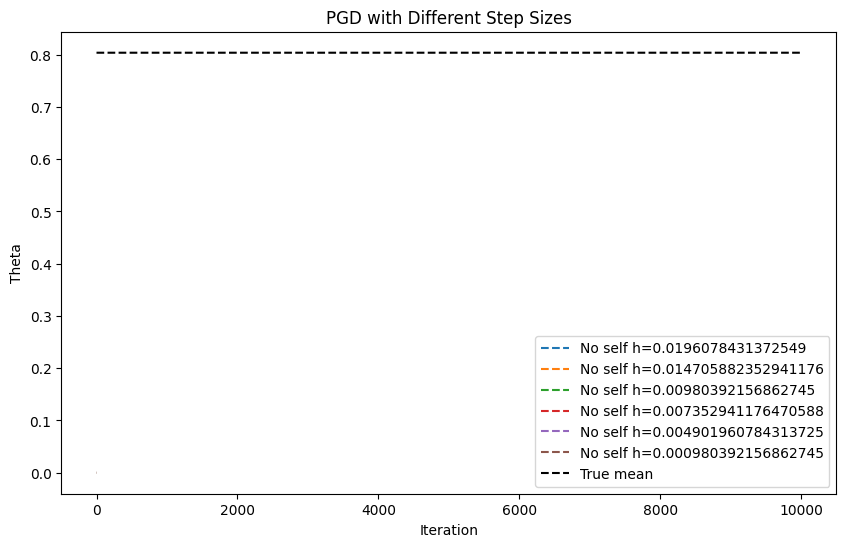

In [39]:
np.random.seed(42)
thdata = 1
# np.random.seed(42)
D=100
M=1
y = np.random.normal(0, 1, (D, M)) + np.random.normal(thdata, 1, (D, M))

epsilon = 0.1  # 10% outliers
num_outliers = int(D * epsilon)

# Randomly select indices for outliers
outlier_indices = np.random.choice(D, num_outliers, replace=False)

# Add large noise to those observations
y[outlier_indices] += np.random.normal(0, 10, num_outliers).reshape(-1, 1)


K = 10000  # Number of steps.
N = 10  # Number of particles.

th0 = np.array([0])  # Initial parameter guess.
X0 = np.zeros((D, N))  # Initial particle cloud.

def theta_opt(X):
    return X.mean()  # Return optimal parameter for particle cloud X.

def ave_grad_th(th, X):
    """Returns theta-gradient of log density averaged over particles."""
    return X[:, 0].size*(theta_opt(X) - th)


def grad_x(y, th, X):
    """Returns x-gradient of log density vectorized over particles."""
    return (th - X)


def interaction_force(Y, Xk, lambda_M):
    # Y: (D, M), Xk: (D, N)
    
    D, M = Y.shape
    _, N = Xk.shape
    
    diff = Y[:, :, None] - Xk[:, None, :]     # (D, M, N)
    sq_dist = np.sum(diff**2, axis=0)         # (M, N)
    
    weights = np.exp(-0.5 * sq_dist)          # (M, N)
    
    Z = np.mean(weights, axis=1, keepdims=True)   # (M, 1)
    
    P = weights / Z                           # (M, N)
    # print('Interaction',weights)
    forces = diff * P[None, :, :]             # (D, M, N)
    
    return np.sum(forces, axis=1) / lambda_M  # (D, N)
# print(interaction_force(Y, Xk,1))


def interaction_force_no_self(Y, Xk, lambda_M):
    D, M = Y.shape
    _, N = Xk.shape
    
    diff = Y[:, :, None] - Xk[:, None, :]
    sq_dist = np.sum(diff**2, axis=0)
    
    weights = np.exp(-0.5 * sq_dist)
    
    total = np.sum(weights, axis=1, keepdims=True)   # (M,1)
    Z = (total - weights) / (N - 1)                  # (M,N)
    
    P = weights / Z
    
    forces = diff * P[None, :, :]
    
    return np.sum(forces, axis=1) / lambda_M
# print(interaction_force_no_self(y, Xk,1))


def Nonlinear_pgd(y, h, K, N, th, lN, X, mode="interaction"):
    D = y.shape[0]
    
    for k in range(K):
        # --- theta update ---
        th = np.append(th, th[k] + h * ave_grad_th(th[k], X))
        
        # --- interaction term ---
        if mode == "interaction":
            inter = interaction_force(y, X,lN)
        elif mode == "no_self":
            inter = interaction_force_no_self(y, X,lN)
        else:
            raise ValueError("mode must be 'interaction' or 'no_self'")
        
        # --- particle update ---
        X = (X 
             + h * (grad_x(y, th[k], X) + lN * inter)
             + np.sqrt(2*h) * np.random.normal(0, 1, (D, N)))
    return th,X


# th_inter,X_inter = Nonlinear_pgd(y, 1/(2+D), K, N, th0, 1, X0.copy(), mode="interaction")

# th_no_inter,X_no_inter = Nonlinear_pgd(y, 1/(2+D), K, N, th0, 1, X0.copy(), mode="no_self")

# print(th_inter)
# print(th_no_inter)

# plt.figure()

# plt.plot(th_inter, label='Interaction')
# plt.plot(th_no_inter, label='No self-interaction')

# plt.plot(y.mean()*np.ones(K), '--', label='True mean')

# plt.legend()
# plt.title("Interaction vs Non-interaction PGD")
# plt.show()


step_sizes = [2/(2+D),1.5/(2+D),1/(2+D),0.75/(2+D),0.5/(2+D),0.1/(2+D)]  # Example step sizes
results = {}

for h in step_sizes:
    # th_inter, X_inter = Nonlinear_pgd(y, h, K, N, th0.copy(), 1, X0.copy(), mode="interaction")
    th_no_inter, X_no_inter = Nonlinear_pgd(y, h, K, N, th0.copy(), 1, X0.copy(), mode="no_self")
    
    results[h] = {
        # "interaction": th_inter,
        "no_interaction": th_no_inter
    }

# --- Plot results ---
plt.figure(figsize=(10,6))

for h in step_sizes:
    # plt.plot(results[h]["interaction"], label=f'Interaction h={h}')
    plt.plot(results[h]["no_interaction"], linestyle='--', label=f'No self h={h}')

plt.plot(y.mean()*np.ones(K), 'k--', label='True mean')
plt.xlabel("Iteration")
plt.ylabel("Theta")
plt.title("PGD with Different Step Sizes")
plt.legend()
plt.show()


Not really sure what happened here but I think because of the exponential terms the exponent is so big and since we take the negative maybe it makes the numerator so small? If I use the logsumexp trick...

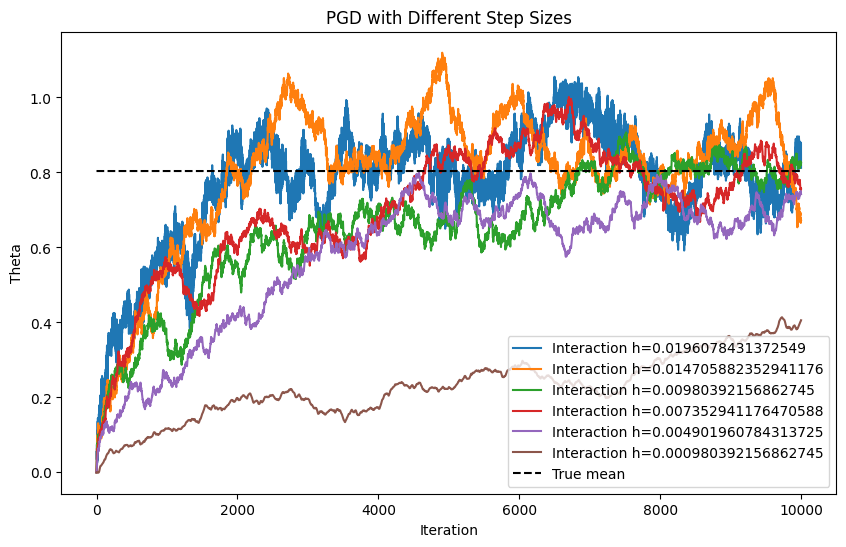

In [40]:
np.random.seed(42)
thdata = 1
# np.random.seed(42)
D=100
M=1
y = np.random.normal(0, 1, (D, M)) + np.random.normal(thdata, 1, (D, M))

epsilon = 0.1  # 10% outliers
num_outliers = int(D * epsilon)

# Randomly select indices for outliers
outlier_indices = np.random.choice(D, num_outliers, replace=False)

# Add large noise to those observations
y[outlier_indices] += np.random.normal(0, 10, num_outliers).reshape(-1, 1)


K = 10000  # Number of steps.
N = 10  # Number of particles.

th0 = np.array([0])  # Initial parameter guess.
X0 = np.zeros((D, N))  # Initial particle cloud.

def theta_opt(X):
    return X.mean()  # Return optimal parameter for particle cloud X.

def ave_grad_th(th, X):
    """Returns theta-gradient of log density averaged over particles."""
    return X[:, 0].size*(theta_opt(X) - th)


def grad_x(y, th, X):
    """Returns x-gradient of log density vectorized over particles."""
    return (th - X)


def interaction_force(Y, Xk, lambda_M):
    D, M = Y.shape
    _, N = Xk.shape
    
    diff = Y[:, :, None] - Xk[:, None, :]        # (D, M, N)
    sq_dist = np.sum(diff**2, axis=0)            # (M, N)
    
    log_w = -0.5 * sq_dist                       # (M, N)
    
    # log-sum-exp trick
    max_log_w = np.max(log_w, axis=1, keepdims=True)   # (M,1)
    w_shifted = np.exp(log_w - max_log_w)              # stable
    
    Z = np.mean(w_shifted, axis=1, keepdims=True)      # (M,1)
    
    P = w_shifted / Z                                 # (M,N)
    
    forces = diff * P[None, :, :]                     # (D,M,N)
    
    return np.sum(forces, axis=1) / lambda_M
# print(interaction_force(Y, Xk,1))


def interaction_force_no_self(Y, Xk, lambda_M):
    D, M = Y.shape
    _, N = Xk.shape
    
    diff = Y[:, :, None] - Xk[:, None, :]
    sq_dist = np.sum(diff**2, axis=0)
    log_w = -0.5 * sq_dist   
    # weights = np.exp(-0.5 * sq_dist)
    max_log_w = np.max(log_w, axis=1, keepdims=True)   # (M,1)
    w_shifted = np.exp(log_w - max_log_w)              # stable
    
    total = np.sum(w_shifted, axis=1, keepdims=True)   # (M,1)
    Z = (total - w_shifted) / (N - 1)                  # (M,N)
    
    P = w_shifted / Z
    
    forces = diff * P[None, :, :]
    
    return np.sum(forces, axis=1) / lambda_M
# print(interaction_force_no_self(y, Xk,1))


def Nonlinear_pgd(y, h, K, N, th, lN, X, mode="interaction"):
    D = y.shape[0]
    
    for k in range(K):
        # --- theta update ---
        th = np.append(th, th[k] + h * ave_grad_th(th[k], X))
        
        # --- interaction term ---
        if mode == "interaction":
            inter = interaction_force(y, X,lN)
        elif mode == "no_self":
            inter = interaction_force_no_self(y, X,lN)
        else:
            raise ValueError("mode must be 'interaction' or 'no_self'")
        
        # --- particle update ---
        X = (X 
             + h * (grad_x(y, th[k], X) + lN * inter)
             + np.sqrt(2*h) * np.random.normal(0, 1, (D, N)))
    return th,X



step_sizes = [2/(2+D),1.5/(2+D),1/(2+D),0.75/(2+D),0.5/(2+D),0.1/(2+D)]  # Example step sizes
results = {}

for h in step_sizes:
    th_inter, X_inter = Nonlinear_pgd(y, h, K, N, th0.copy(), 1, X0.copy(), mode="interaction")
    # th_no_inter, X_no_inter = Nonlinear_pgd(y, h, K, N, th0.copy(), 1, X0.copy(), mode="no_self")
    
    results[h] = {
        "interaction": th_inter
        # "no_interaction": th_no_inter
    }

# --- Plot results ---
plt.figure(figsize=(10,6))

for h in step_sizes:
    plt.plot(results[h]["interaction"], label=f'Interaction h={h}')
    # plt.plot(results[h]["no_interaction"], linestyle='--', label=f'No self h={h}')

plt.plot(y.mean()*np.ones(K), 'k--', label='True mean')
plt.xlabel("Iteration")
plt.ylabel("Theta")
plt.title("PGD with Different Step Sizes")
plt.legend()
plt.show()


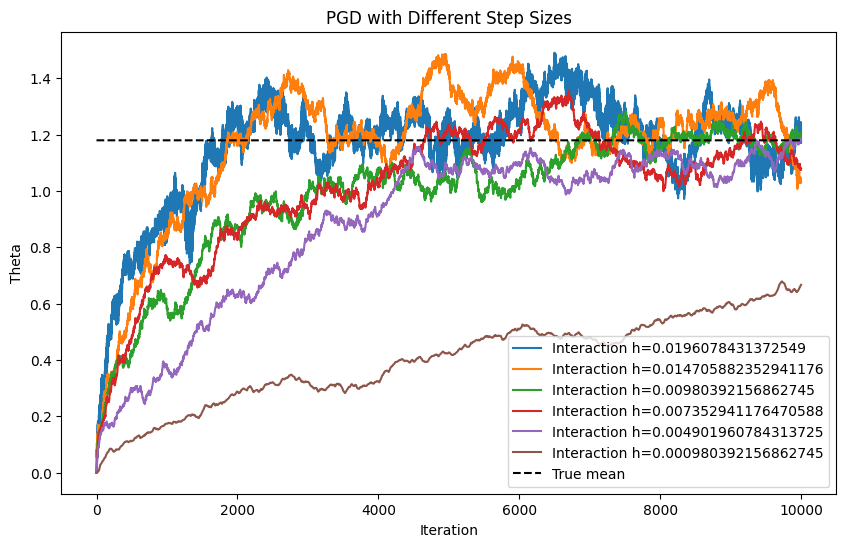

In [41]:
np.random.seed(42)
thdata = 1
# np.random.seed(42)
D=100
M=1
y = np.random.normal(0, 1, (D, M)) + np.random.normal(thdata, 1, (D, M))

epsilon = 0.2  # 20% outliers
num_outliers = int(D * epsilon)

# Randomly select indices for outliers
outlier_indices = np.random.choice(D, num_outliers, replace=False)

# Add large noise to those observations
y[outlier_indices] += np.random.normal(0, 10, num_outliers).reshape(-1, 1)


K = 10000  # Number of steps.
N = 10  # Number of particles.

th0 = np.array([0])  # Initial parameter guess.
X0 = np.zeros((D, N))  # Initial particle cloud.

def theta_opt(X):
    return X.mean()  # Return optimal parameter for particle cloud X.

def ave_grad_th(th, X):
    """Returns theta-gradient of log density averaged over particles."""
    return X[:, 0].size*(theta_opt(X) - th)


def grad_x(y, th, X):
    """Returns x-gradient of log density vectorized over particles."""
    return (th - X)


def interaction_force(Y, Xk, lambda_M):
    D, M = Y.shape
    _, N = Xk.shape
    
    diff = Y[:, :, None] - Xk[:, None, :]        # (D, M, N)
    sq_dist = np.sum(diff**2, axis=0)            # (M, N)
    
    log_w = -0.5 * sq_dist                       # (M, N)
    
    # log-sum-exp trick
    max_log_w = np.max(log_w, axis=1, keepdims=True)   # (M,1)
    w_shifted = np.exp(log_w - max_log_w)              # stable
    
    Z = np.mean(w_shifted, axis=1, keepdims=True)      # (M,1)
    
    P = w_shifted / Z                                 # (M,N)
    
    forces = diff * P[None, :, :]                     # (D,M,N)
    
    return np.sum(forces, axis=1) / lambda_M
# print(interaction_force(Y, Xk,1))


def interaction_force_no_self(Y, Xk, lambda_M):
    D, M = Y.shape
    _, N = Xk.shape
    
    diff = Y[:, :, None] - Xk[:, None, :]
    sq_dist = np.sum(diff**2, axis=0)
    log_w = -0.5 * sq_dist   
    # weights = np.exp(-0.5 * sq_dist)
    max_log_w = np.max(log_w, axis=1, keepdims=True)   # (M,1)
    w_shifted = np.exp(log_w - max_log_w)              # stable
    
    total = np.sum(w_shifted, axis=1, keepdims=True)   # (M,1)
    Z = (total - w_shifted) / (N - 1)                  # (M,N)
    
    P = w_shifted / Z
    
    forces = diff * P[None, :, :]
    
    return np.sum(forces, axis=1) / lambda_M
# print(interaction_force_no_self(y, Xk,1))


def Nonlinear_pgd(y, h, K, N, th, lN, X, mode="interaction"):
    D = y.shape[0]
    
    for k in range(K):
        # --- theta update ---
        th = np.append(th, th[k] + h * ave_grad_th(th[k], X))
        
        # --- interaction term ---
        if mode == "interaction":
            inter = interaction_force(y, X,lN)
        elif mode == "no_self":
            inter = interaction_force_no_self(y, X,lN)
        else:
            raise ValueError("mode must be 'interaction' or 'no_self'")
        
        # --- particle update ---
        X = (X 
             + h * (grad_x(y, th[k], X) + lN * inter)
             + np.sqrt(2*h) * np.random.normal(0, 1, (D, N)))
    return th,X



step_sizes = [2/(2+D),1.5/(2+D),1/(2+D),0.75/(2+D),0.5/(2+D),0.1/(2+D)]  # Example step sizes
results = {}

for h in step_sizes:
    th_inter, X_inter = Nonlinear_pgd(y, h, K, N, th0.copy(), 1, X0.copy(), mode="interaction")
    # th_no_inter, X_no_inter = Nonlinear_pgd(y, h, K, N, th0.copy(), 1, X0.copy(), mode="no_self")
    
    results[h] = {
        "interaction": th_inter
        # "no_interaction": th_no_inter
    }

# --- Plot results ---
plt.figure(figsize=(10,6))

for h in step_sizes:
    plt.plot(results[h]["interaction"], label=f'Interaction h={h}')
    # plt.plot(results[h]["no_interaction"], linestyle='--', label=f'No self h={h}')

plt.plot(y.mean()*np.ones(K), 'k--', label='True mean')
plt.xlabel("Iteration")
plt.ylabel("Theta")
plt.title("PGD with Different Step Sizes")
plt.legend()
plt.show()


Interestingly if we add more Ms (i.e. take M=20) then for some step sizes it appears to work.

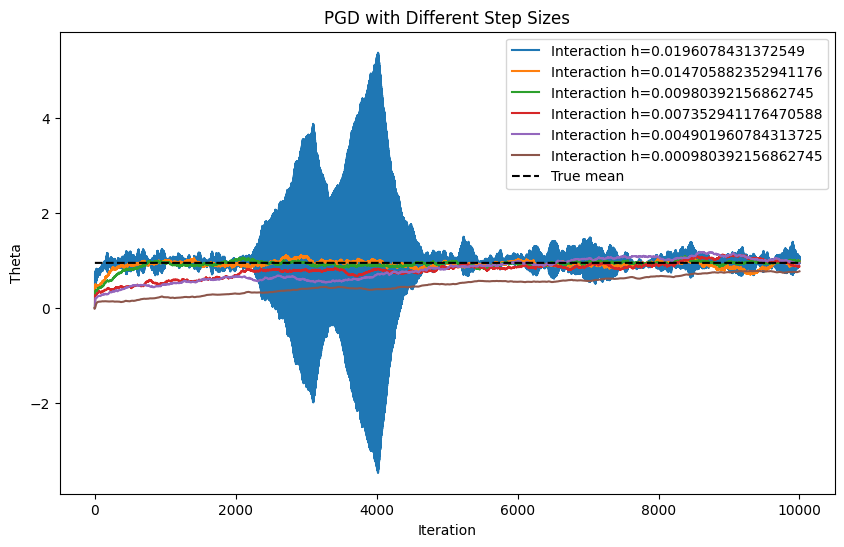

In [42]:
np.random.seed(42)
thdata = 1
# np.random.seed(42)
D=100
M=20
y = np.random.normal(0, 1, (D, M)) + np.random.normal(thdata, 1, (D, M))

epsilon = 0.1  # 10% outliers
num_outliers = int(D * epsilon)

# Randomly select indices for outliers
outlier_indices = np.random.choice(D, num_outliers, replace=False)

# Add large noise to those observations
y[outlier_indices] += np.random.normal(0, 10, num_outliers).reshape(-1, 1)


K = 10000  # Number of steps.
N = 10  # Number of particles.

th0 = np.array([0])  # Initial parameter guess.
X0 = np.zeros((D, N))  # Initial particle cloud.

def theta_opt(X):
    return X.mean()  # Return optimal parameter for particle cloud X.

def ave_grad_th(th, X):
    """Returns theta-gradient of log density averaged over particles."""
    return X[:, 0].size*(theta_opt(X) - th)


def grad_x(y, th, X):
    """Returns x-gradient of log density vectorized over particles."""
    return (th - X)


def interaction_force(Y, Xk, lambda_M):
    # Y: (D, M), Xk: (D, N)
    
    D, M = Y.shape
    _, N = Xk.shape
    
    diff = Y[:, :, None] - Xk[:, None, :]     # (D, M, N)
    sq_dist = np.sum(diff**2, axis=0)         # (M, N)
    
    weights = np.exp(-0.5 * sq_dist)          # (M, N)
    
    Z = np.mean(weights, axis=1, keepdims=True)   # (M, 1)
    
    P = weights / Z                           # (M, N)
    # print('Interaction',weights)
    forces = diff * P[None, :, :]             # (D, M, N)
    
    return np.sum(forces, axis=1) / lambda_M  # (D, N)
# print(interaction_force(Y, Xk,1))


def interaction_force_no_self(Y, Xk, lambda_M):
    D, M = Y.shape
    _, N = Xk.shape
    
    diff = Y[:, :, None] - Xk[:, None, :]
    sq_dist = np.sum(diff**2, axis=0)
    
    weights = np.exp(-0.5 * sq_dist)
    
    total = np.sum(weights, axis=1, keepdims=True)   # (M,1)
    Z = (total - weights) / (N - 1)                  # (M,N)
    
    P = weights / Z
    
    forces = diff * P[None, :, :]
    
    return np.sum(forces, axis=1) / lambda_M
# print(interaction_force_no_self(y, Xk,1))


def Nonlinear_pgd(y, h, K, N, th, lN, X, mode="interaction"):
    D = y.shape[0]
    
    for k in range(K):
        # --- theta update ---
        th = np.append(th, th[k] + h * ave_grad_th(th[k], X))
        
        # --- interaction term ---
        if mode == "interaction":
            inter = interaction_force(y, X,lN)
        elif mode == "no_self":
            inter = interaction_force_no_self(y, X,lN)
        else:
            raise ValueError("mode must be 'interaction' or 'no_self'")
        
        # --- particle update ---
        X = (X 
             + h * (grad_x(y, th[k], X) + lN * inter)
             + np.sqrt(2*h) * np.random.normal(0, 1, (D, N)))
    return th,X


# th_inter,X_inter = Nonlinear_pgd(y, 1/(2+D), K, N, th0, 1, X0.copy(), mode="interaction")

# th_no_inter,X_no_inter = Nonlinear_pgd(y, 1/(2+D), K, N, th0, 1, X0.copy(), mode="no_self")

# print(th_inter)
# print(th_no_inter)

# plt.figure()

# plt.plot(th_inter, label='Interaction')
# plt.plot(th_no_inter, label='No self-interaction')

# plt.plot(y.mean()*np.ones(K), '--', label='True mean')

# plt.legend()
# plt.title("Interaction vs Non-interaction PGD")
# plt.show()


step_sizes = [2/(2+D),1.5/(2+D),1/(2+D),0.75/(2+D),0.5/(2+D),0.1/(2+D)]  # Example step sizes
results = {}

for h in step_sizes:
    th_inter, X_inter = Nonlinear_pgd(y, h, K, N, th0.copy(), 1, X0.copy(), mode="interaction")
    # th_no_inter, X_no_inter = Nonlinear_pgd(y, h, K, N, th0.copy(), 1, X0.copy(), mode="no_self")
    
    results[h] = {
        "interaction": th_inter
        # "no_interaction": th_no_inter
    }

# --- Plot results ---
plt.figure(figsize=(10,6))

for h in step_sizes:
    plt.plot(results[h]["interaction"], label=f'Interaction h={h}')
    # plt.plot(results[h]["no_interaction"], linestyle='--', label=f'No self h={h}')

plt.plot(y.mean()*np.ones(K), 'k--', label='True mean')
plt.xlabel("Iteration")
plt.ylabel("Theta")
plt.title("PGD with Different Step Sizes")
plt.legend()
plt.show()


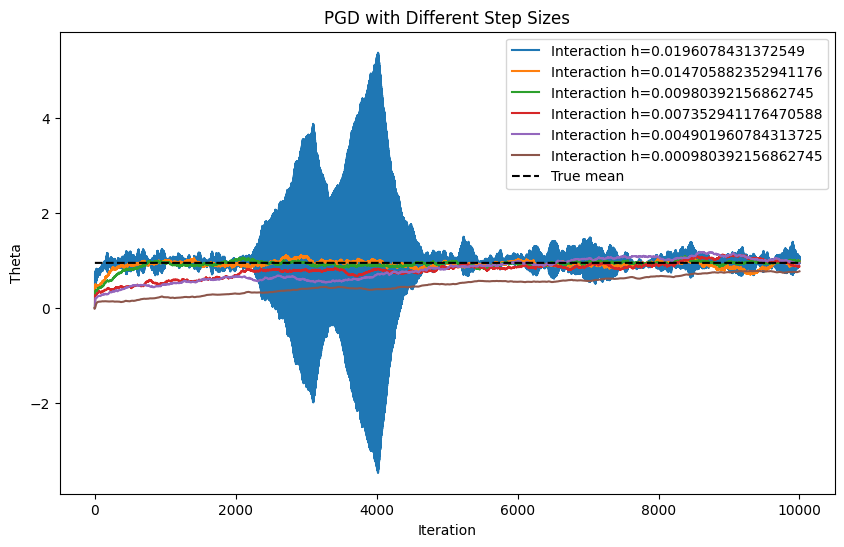

In [43]:
np.random.seed(42)
thdata = 1
# np.random.seed(42)
D=100
M=20
y = np.random.normal(0, 1, (D, M)) + np.random.normal(thdata, 1, (D, M))

epsilon = 0.1  # 10% outliers
num_outliers = int(D * epsilon)

# Randomly select indices for outliers
outlier_indices = np.random.choice(D, num_outliers, replace=False)

# Add large noise to those observations
y[outlier_indices] += np.random.normal(0, 10, num_outliers).reshape(-1, 1)


K = 10000  # Number of steps.
N = 10  # Number of particles.

th0 = np.array([0])  # Initial parameter guess.
X0 = np.zeros((D, N))  # Initial particle cloud.

def theta_opt(X):
    return X.mean()  # Return optimal parameter for particle cloud X.

def ave_grad_th(th, X):
    """Returns theta-gradient of log density averaged over particles."""
    return X[:, 0].size*(theta_opt(X) - th)


def grad_x(y, th, X):
    """Returns x-gradient of log density vectorized over particles."""
    return (th - X)


def interaction_force(Y, Xk, lambda_M):
    D, M = Y.shape
    _, N = Xk.shape
    
    diff = Y[:, :, None] - Xk[:, None, :]        # (D, M, N)
    sq_dist = np.sum(diff**2, axis=0)            # (M, N)
    
    log_w = -0.5 * sq_dist                       # (M, N)
    
    # log-sum-exp trick
    max_log_w = np.max(log_w, axis=1, keepdims=True)   # (M,1)
    w_shifted = np.exp(log_w - max_log_w)              # stable
    
    Z = np.mean(w_shifted, axis=1, keepdims=True)      # (M,1)
    
    P = w_shifted / Z                                 # (M,N)
    
    forces = diff * P[None, :, :]                     # (D,M,N)
    
    return np.sum(forces, axis=1) / lambda_M
# print(interaction_force(Y, Xk,1))


def interaction_force_no_self(Y, Xk, lambda_M):
    D, M = Y.shape
    _, N = Xk.shape
    
    diff = Y[:, :, None] - Xk[:, None, :]
    sq_dist = np.sum(diff**2, axis=0)
    log_w = -0.5 * sq_dist   
    # weights = np.exp(-0.5 * sq_dist)
    max_log_w = np.max(log_w, axis=1, keepdims=True)   # (M,1)
    w_shifted = np.exp(log_w - max_log_w)              # stable
    
    total = np.sum(w_shifted, axis=1, keepdims=True)   # (M,1)
    Z = (total - w_shifted) / (N - 1)                  # (M,N)
    
    P = w_shifted / Z
    
    forces = diff * P[None, :, :]
    
    return np.sum(forces, axis=1) / lambda_M
# print(interaction_force_no_self(y, Xk,1))


def Nonlinear_pgd(y, h, K, N, th, lN, X, mode="interaction"):
    D = y.shape[0]
    
    for k in range(K):
        # --- theta update ---
        th = np.append(th, th[k] + h * ave_grad_th(th[k], X))
        
        # --- interaction term ---
        if mode == "interaction":
            inter = interaction_force(y, X,lN)
        elif mode == "no_self":
            inter = interaction_force_no_self(y, X,lN)
        else:
            raise ValueError("mode must be 'interaction' or 'no_self'")
        
        # --- particle update ---
        X = (X 
             + h * (grad_x(y, th[k], X) + lN * inter)
             + np.sqrt(2*h) * np.random.normal(0, 1, (D, N)))
    return th,X



step_sizes = [2/(2+D),1.5/(2+D),1/(2+D),0.75/(2+D),0.5/(2+D),0.1/(2+D)]  # Example step sizes
results = {}

for h in step_sizes:
    th_inter, X_inter = Nonlinear_pgd(y, h, K, N, th0.copy(), 1, X0.copy(), mode="interaction")
    # th_no_inter, X_no_inter = Nonlinear_pgd(y, h, K, N, th0.copy(), 1, X0.copy(), mode="no_self")
    
    results[h] = {
        "interaction": th_inter
        # "no_interaction": th_no_inter
    }

# --- Plot results ---
plt.figure(figsize=(10,6))

for h in step_sizes:
    plt.plot(results[h]["interaction"], label=f'Interaction h={h}')
    # plt.plot(results[h]["no_interaction"], linestyle='--', label=f'No self h={h}')

plt.plot(y.mean()*np.ones(K), 'k--', label='True mean')
plt.xlabel("Iteration")
plt.ylabel("Theta")
plt.title("PGD with Different Step Sizes")
plt.legend()
plt.show()


## More experiments ##
Cauchy?

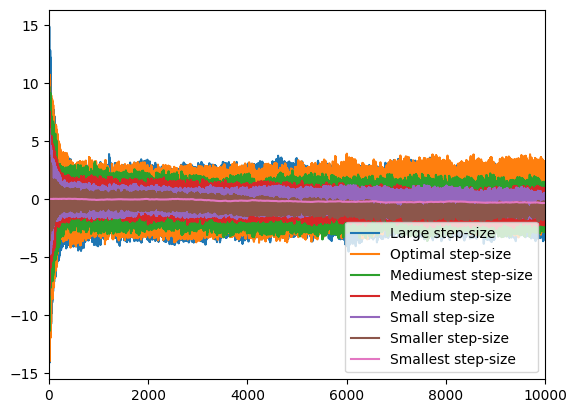

In [44]:
import numpy as np  # Numpy for computations.
import matplotlib.pyplot as plt  # Pyplot for plots.
np.random.seed(42)
def pgd(y, h, K, N, th, X,gamma):
    """Particle Gradient Ascent Algorithm. Returns parameter estimates."""
    D = y.size  # Extract dimension of latent variables.
    for k in range(K):
        # Update parameter estimate:
        th = np.append(th, th[k] + h*ave_grad_th_cauchy(th[k], X,gamma))
        # Update particle cloud:
        X = (X + h*grad_x_cauchy(th[k], X,gamma)
               + np.sqrt(2*h)*np.random.normal(0, 1, (D, N)))
    return th


def pqn(y, h, K, N, th, X):
    """Particle Quasi-Newton Algorithm. Returns parameter estimates."""
    D = y.size  # Extract dimension of latent variables.
    for k in range(K):
        # Update parameter estimate:
        th = np.append(th, th[k] 
                            + h*(ave_neg_hess_th(D)**-1)*ave_grad_th(th[k], X))
        # Update particle cloud:
        X = (X + h*grad_x(y, th[k], X)
               + np.sqrt(2*h)*np.random.normal(0, 1, (D, N)))
    return th


def pmgd(y, h, K, N, X):
    """Particle Marginal Gradient Ascent Algorithm. 
    Returns parameter estimates.
    """
    D = y.size  # Extract dimension of latent variables.
    th = np.array([theta_opt(X)])  # Compute initial parameter estimate.
    for k in range(K):
        # Update particle cloud:
        X = (X + h*grad_x(y, th[k], X)
               + np.sqrt(2*h)*np.random.normal(0, 1, (D, N)))
        th = np.append(th, theta_opt(X))  # Update parameter estimate.
    return th


def em(y, K, th):
    """Expectation Maximization Algorithm. Returns parameter estimates."""
    for k in range(K):
        th = np.append(th, th[k]/2 + y.mean()/2)  # Update parameter estimate.
    return th


# Auxiliary functions.

def theta_opt(X):
    return X.mean()  # Return optimal parameter for particle cloud X.


def ave_grad_th(th, X):
    """Returns theta-gradient of log density averaged over particles."""
    return X[:, 0].size*(theta_opt(X) - th)

def grad_x_cauchy(th, X, gamma):
    return -2 * (X - th) / (gamma**2 + (X - th)**2)

def ave_grad_th_cauchy(th, X, gamma):
    return np.sum(-2 * (th - X) / (gamma**2 + (X - th)**2))



def ave_neg_hess_th(D):
    """Returns negative-theta-Hessian of log density averaged over particles.
    """
    return D


def grad_x(y, th, X):
    """Returns x-gradient of log density vectorized over particles."""
    return (y + th - 2*X)


D = 100  # Dimensionality of latent variables.
thdata = 1  # Parameter value used to generate the data.
gamma=1
# Generate the data:
y = np.random.normal(0, 1, (D, 1)) + np.random.normal(thdata, 1, (D, 1))

K = 10000  # Number of steps.
N = 10  # Number of particles.

th0 = np.array([0])  # Initial parameter guess.
X0 = np.zeros((D, N))  # Initial particle cloud.

# Run PGD using three different step-sizes:
th_large = pgd(y, 2.05/(2+D), K, N, th0, X0,gamma)  # Large step-size
th_optimal = pgd(y, 2/(2+D), K, N, th0, X0,gamma)  # Optimal step-size 
th_mediumest = pgd(y, 1.5/(2+D), K, N, th0, X0,gamma)  # Small step-size
th_medium = pgd(y, 1/(2+D), K, N, th0, X0,gamma)  # Small step-size
th_small = pgd(y, 0.75/(2+D), K, N, th0, X0,gamma)  # Small step-size
th_smaller = pgd(y, 0.5/(2+D), K, N, th0, X0,gamma)  # Small step-size
th_smallest = pgd(y, 0.1/(2+D), K, N, th0, X0,gamma)  # Small step-size

# Plot parameter estimates as a function of step number k:
plt.figure()
plt.plot(th_large, label='Large step-size')
plt.plot(th_optimal, label='Optimal step-size')
plt.plot(th_mediumest, label='Mediumest step-size')
plt.plot(th_medium, label='Medium step-size')
plt.plot(th_small, label='Small step-size')
plt.plot(th_smaller, label='Smaller step-size')
plt.plot(th_smallest, label='Smallest step-size')
plt.legend(loc='lower right')
# plt.ylim([0, 1.2*y.mean()])
plt.xlim([0, K])
plt.show()



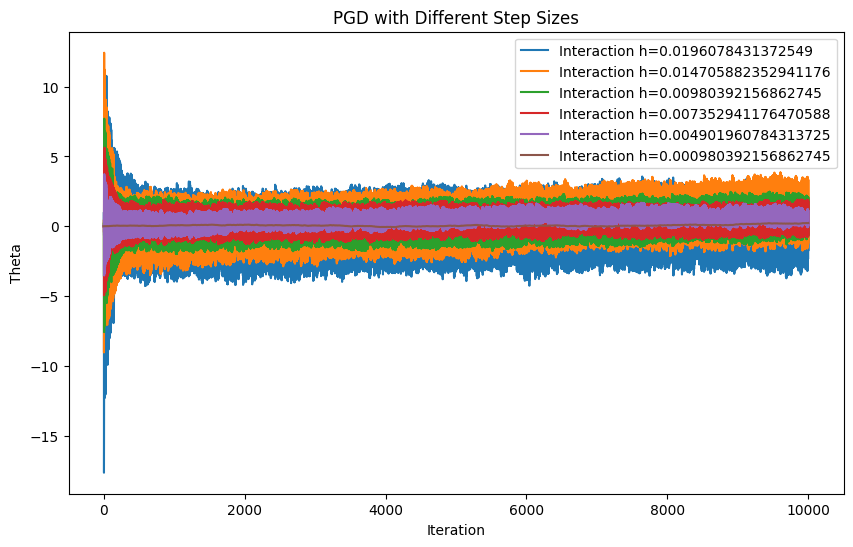

In [45]:
np.random.seed(42)
thdata = 1
# np.random.seed(42)
D=100
M=1
y = np.random.normal(0, 1, (D, M)) + np.random.normal(thdata, 1, (D, M))
K = 10000  # Number of steps.
N = 10  # Number of particles.

th0 = np.array([0])  # Initial parameter guess.
X0 = np.zeros((D, N))  # Initial particle cloud.


def grad_x_cauchy(th, X, gamma):
    return -2 * (X - th) / (gamma**2 + (X - th)**2)

def ave_grad_th_cauchy(th, X, gamma):
    return np.sum(-2 * (th - X) / (gamma**2 + (X - th)**2))

def Nonlinear_pgd_cauchy(y, h, K, N, th, lN, X, gamma, mode="interaction"):
    D = y.shape[0]
    
    for k in range(K):
        # --- theta update ---
        th = np.append(th, th[k] + h * ave_grad_th_cauchy(th[k], X, gamma))
        
        # --- interaction term ---
        if mode == "interaction":
            inter = interaction_force(y, X, lN)
        elif mode == "no_self":
            inter = interaction_force_no_self(y, X, lN)
        else:
            raise ValueError("mode must be 'interaction' or 'no_self'")
        
        # --- particle update ---
        X = (X 
             + h * (grad_x_cauchy(th[k], X, gamma) + lN * inter)
             + np.sqrt(2*h) * np.random.normal(0, 1, (D, N)))
    
    return th, X


step_sizes = [2/(2+D),1.5/(2+D),1/(2+D),0.75/(2+D),0.5/(2+D),0.1/(2+D)]  # Example step sizes
results = {}

for h in step_sizes:
    th_inter, X_inter = Nonlinear_pgd_cauchy(y, h, K=K, N=N, th=th0.copy(), lN=1, X=X0.copy(), gamma=1.0)
    # th_no_inter, X_no_inter = Nonlinear_pgd(y, h, K, N, th0.copy(), 1, X0.copy(), mode="no_self")
    
    results[h] = {
        "interaction": th_inter
        # "no_interaction": th_no_inter
    }

# --- Plot results ---
plt.figure(figsize=(10,6))

for h in step_sizes:
    plt.plot(results[h]["interaction"], label=f'Interaction h={h}')
    # plt.plot(results[h]["no_interaction"], linestyle='--', label=f'No self h={h}')

plt.xlabel("Iteration")
plt.ylabel("Theta")
plt.title("PGD with Different Step Sizes")
plt.legend()
plt.show()


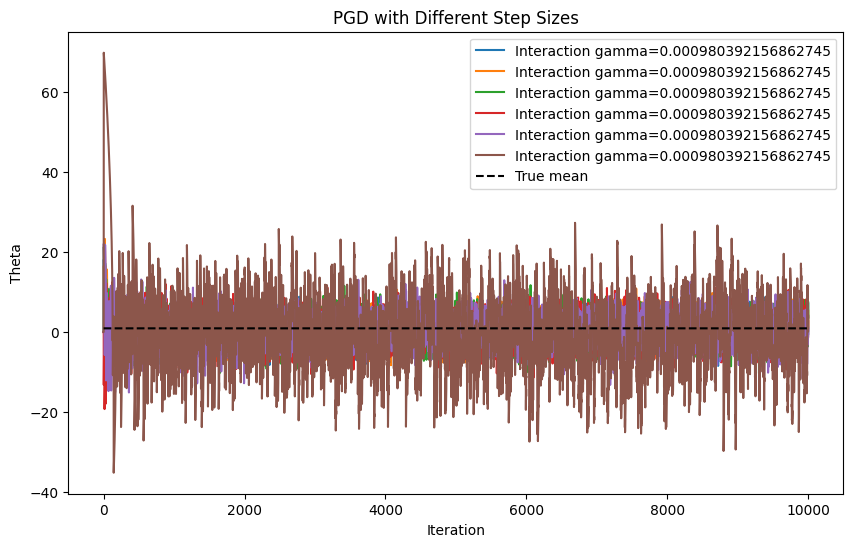

In [46]:

np.random.seed(42)
thdata = 1
# np.random.seed(42)
D=100
M=1
y = np.random.normal(0, 1, (D, M)) + np.random.normal(thdata, 1, (D, M))
K = 10000  # Number of steps.
N = 10  # Number of particles.

th0 = np.array([0])  # Initial parameter guess.
X0 = np.zeros((D, N))  # Initial particle cloud.


def grad_x_cauchy(th, X, gamma):
    return -2 * (X - th) / (gamma**2 + (X - th)**2)

def ave_grad_th_cauchy(th, X, gamma):
    return np.sum(-2 * (th - X) / (gamma**2 + (X - th)**2))

def Nonlinear_pgd_cauchy(y, h, K, N, th, lN, X, gamma, mode="interaction"):
    D = y.shape[0]
    
    for k in range(K):
        # --- theta update ---
        th = np.append(th, th[k] + h * ave_grad_th_cauchy(th[k], X, gamma))
        
        # --- interaction term ---
        if mode == "interaction":
            inter = interaction_force(y, X, lN)
        elif mode == "no_self":
            inter = interaction_force_no_self(y, X, lN)
        else:
            raise ValueError("mode must be 'interaction' or 'no_self'")
        
        # --- particle update ---
        X = (X 
             + h * (grad_x_cauchy(th[k], X, gamma) + lN * inter)
             + np.sqrt(2*h) * np.random.normal(0, 1, (D, N)))
    
    return th, X


gammas = [2,1.5,1,0.75,0.5,0.1]  # Example step sizes
results = {}

for gamma in step_sizes:
    th_inter, X_inter = Nonlinear_pgd_cauchy(y, h=1/(2+D), K=K, N=N, th=th0.copy(), lN=1, X=X0.copy(), gamma=gamma)
    # th_no_inter, X_no_inter = Nonlinear_pgd(y, h, K, N, th0.copy(), 1, X0.copy(), mode="no_self")
    
    results[gamma] = {
        "interaction": th_inter
        # "no_interaction": th_no_inter
    }

# --- Plot results ---
plt.figure(figsize=(10,6))

for h in step_sizes:
    plt.plot(results[h]["interaction"], label=f'Interaction gamma={gamma}')
    # plt.plot(results[h]["no_interaction"], linestyle='--', label=f'No self h={h}')

plt.plot(y.mean()*np.ones(K), 'k--', label='True mean')
plt.xlabel("Iteration")
plt.ylabel("Theta")
plt.title("PGD with Different Step Sizes")
plt.legend()
plt.show()
